# Exercise 10-1: Create a Linear Regression Model on Fish Data

This Notebook is a cleaned version of [this notebook](ex_10-1_fish.ipynb)

## Setup and Load Data

1. Import Libraries, Modules, and Functions

Beginning by importing the required tools:

- `pandas`: data structuring
- `seaborn`: statistical visualization
- `LinearRegression` from `sklearn.linear_model`: build predictive model
- `train_test_split` from `sklearn.selection`: properly split data for training and validation
- `matplotlib.pyplot`: provide the foundational plotting engine used by `seaborn` to customize titles, labels, and figure structures

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2. Load Data

Loading the `Fish.csv` file into a Pandas DataFrame object named `fish`
- `pd.read_csv()` reads a csv file into a structured DataFrame
- `head()` displays the first 5 rows of the dataset to check that the columns and data have loaded correctly

In [2]:
fish = pd.read_csv(r'..\data\Fish.csv')

## Exploratory Data Analysis (EDA) *new*
`.shape` display the number of rows and columns.
    - `[0]` as rows
    - `[1]` as columns

In [3]:
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [4]:
print(f"Number of row: {fish.shape[0]}\nNumber of column: {fish.shape[1]}")

Number of row: 159
Number of column: 7


In [5]:
fish.isnull().sum() # check for missing values

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [6]:
fish.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


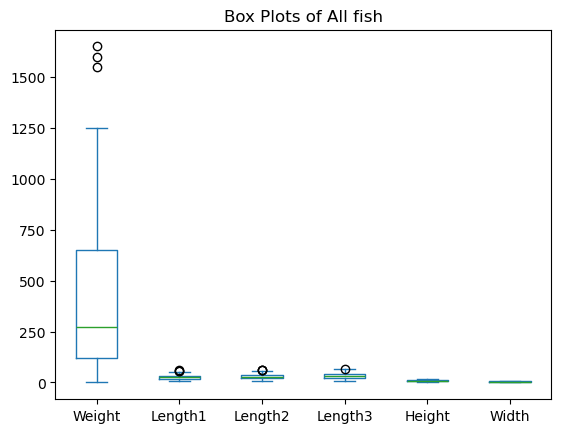

In [7]:
fish.plot(kind='box', layout=(2,2), sharex=False, sharey=False).set_title("Box Plots of All fish");

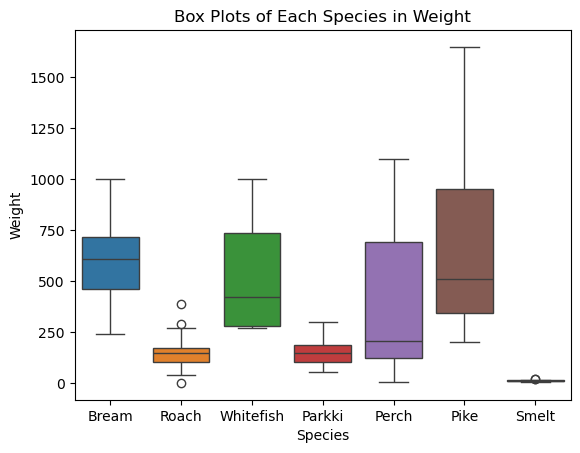

In [ ]:
sns.boxplot(data=fish, x=fish['Species'], y=fish['Weight'], hue='Species').set(title='Box Plots of Each Species in Weight');

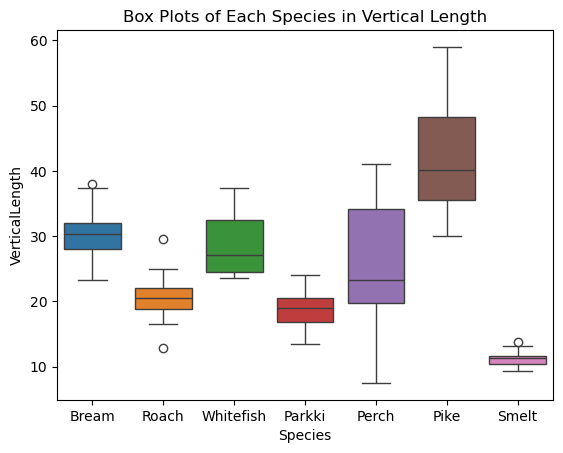

In [ ]:
sns.boxplot(data=fish,x = fish['Species'], y=fish['VerticalLength'], hue=fish['Species']).set(title='Box Plots of Each Species in Vertical Length');

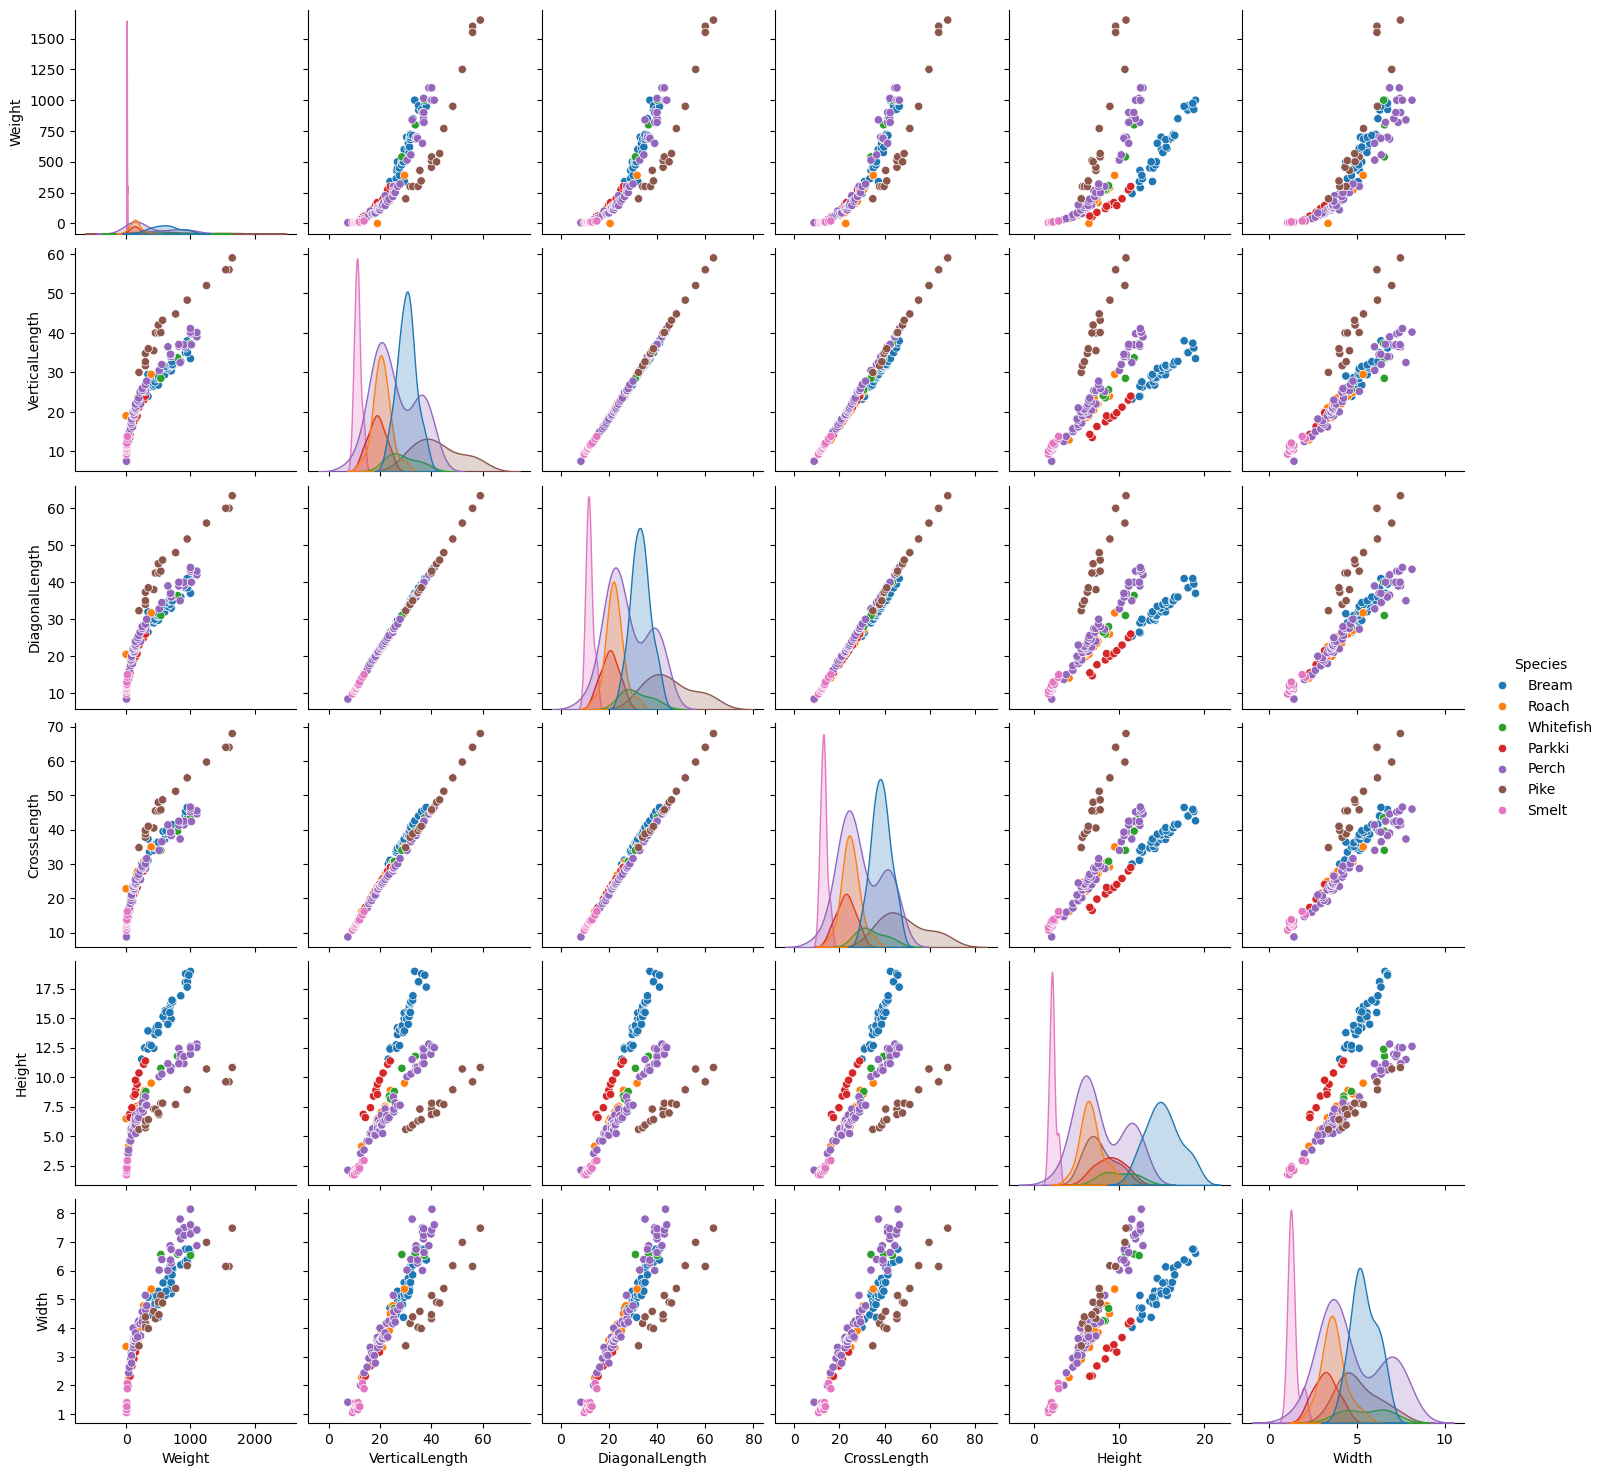

In [ ]:
sns.pairplot(data=fish, hue="Species");

## Clean the Data

**Rename Columns for Better Descriptions**

The original dataset usese the generic labels `Length1`, `Length2`, and `Length3`. To make the dataset self-documenting and easier to analyze, we rename these columns to `VerticalLength`, `DiagonalLength`, and `CrossLength` respectively.

**Code Explanation**

`.rename(columns=...)` accepts a dictionary mapping old column headers to new string names

In [8]:
## Mapping new names to old column names
new_names = {
    'Length1': 'VerticalLength',
    'Length2': 'DiagonalLength',
    'Length3': 'CrossLength'
}

fish = fish.rename(columns=new_names) # renaming based on the mapping
fish.head() # verify the renaming

,Species,Weight,VerticalLength,DiagonalLength,CrossLength,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [9]:
# fish.to_csv('Fish.csv', index = False) # save cleaned dataset

## Identify a Correlation

- **Isolate Numerical Data**: Linear regression requires numerical inputs. Therefore, subseting the DataFrame to separate the continuous variables from the categorical variable (`Species`).
- **Compute the Correlation Matrix**: Evaluating how strongly each physical feature relates to the fish's `Weight` by generating a **correlation matrix** in descending order. 
- **Code Explanation**:
    - The double brackets (`[[...]]`) are used in Pandas to select a list of specific column names, returning a new DataFrame subset.
    - `.corr()` computes the pairwise Pearson correlation coefficients between all numeric columns. Subsetting with `[['Weight]]` focuses exclusively on the relationship of features against our target variable, and `.sort_values(by='Weight', ascending=False)` orders them from strongest positive relationship to weakest.

In [10]:
fish_numeric = fish[['Weight', 'VerticalLength', 'DiagonalLength', 'CrossLength', 'Height', 'Width']]
fish_numeric.corr()[['Weight']].sort_values(by='Weight', ascending=False)

,Weight
Weight,1.000000
CrossLength,0.923044
DiagonalLength,0.918618
VerticalLength,0.915712
Width,0.886507
Height,0.724345


**Interpretation of the Correlation Matrix**

- Pearson correlation values range from -1 to 1, where `1` represents a perfect positive linear relationship, `-1` a perfect negative linear relationship, and `0` no linear relationship.
- `CrossLength` (0.923), `DiagonalLength` (0.9186), and `VerticalLength` (0.9157) show exceptionally strong positive linear correlations with `Weight`. 
- `Width` (0.8865) and `Height` (0.7243) also share a strong positive relationship with `Weight`, though slightly less intense than the length measurements.

**Conclusion**: Since all features share high positive correlation coefficients with `Weight`, we expect a fish's weight to predictably scale upwards as any of these spatial dimensions increase.

### Visualize via a Heatmap

To easily see the overall dataset relationships and check for potential multi-collinearity, we plot the full correlation matrix as a color-coded heatmap.

**Code Explanation**
- `plt.figure(figsize=(8, 6))` configures the display dimensions of our output plot.

- `sns.heatmap()` generates the color grid.

- `cmap='coolwarm'` sets the color spectrum (blue for negative, red for positive).

- `fmt=".4f"` forces the decimal values inside each block to display to 4 decimal places.

- `vmin` and `vmax` anchor the spectrum boundaries safely between -1 and 1.

- `plt.show()` forces the visual rendering.

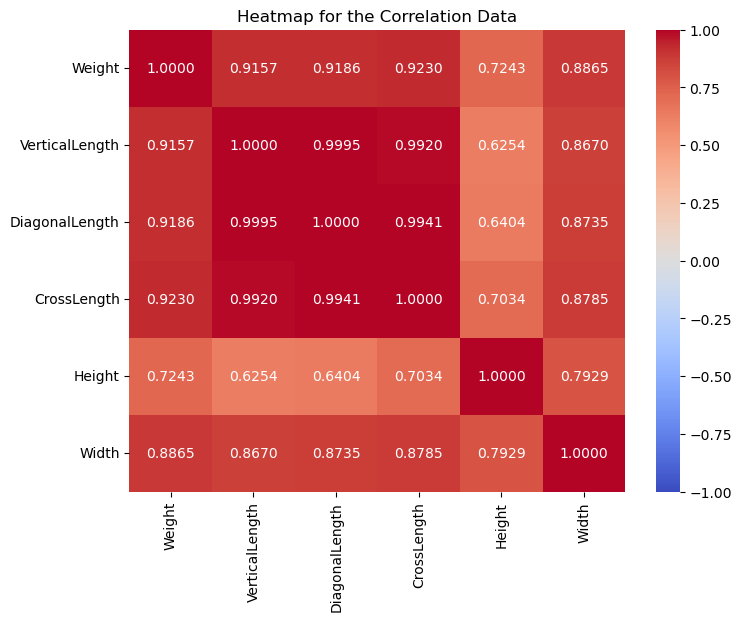

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(fish_numeric.corr(), annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title('Heatmap for the Correlation Data')
plt.show()

### Visualize via Scatter Plots

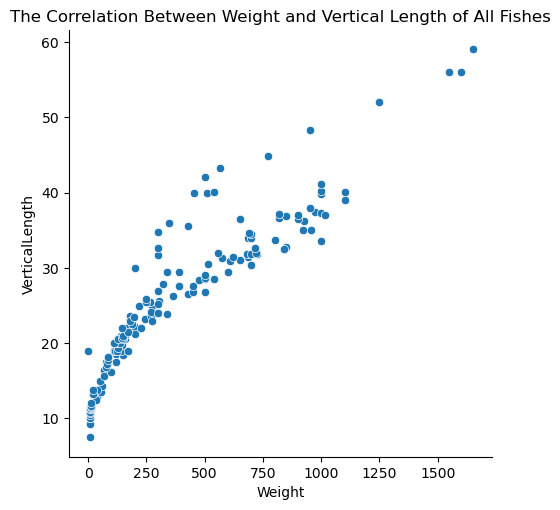

In [12]:
sns.relplot(data=fish_numeric, x="Weight", y="VerticalLength").set(title="The Correlation Between Weight and Vertical Length of All Fishes");

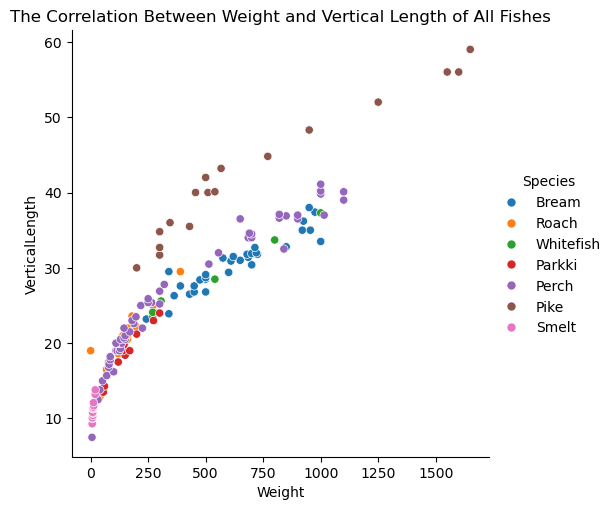

In [13]:
sns.relplot(data=fish, x="Weight", y="VerticalLength", hue='Species').set(title="The Correlation Between Weight and Vertical Length of All Fishes");

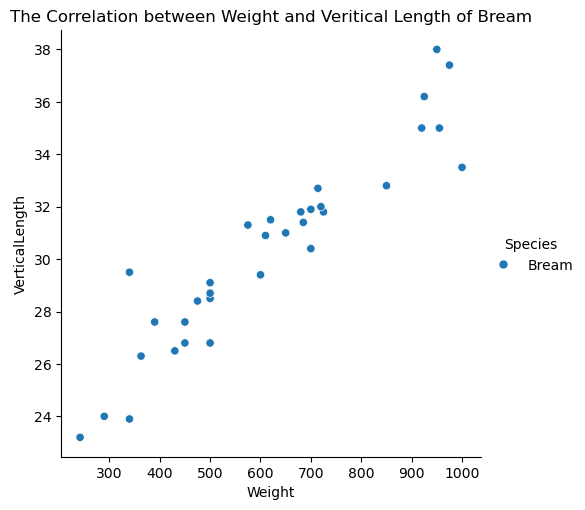

In [14]:
sns.relplot(data=fish[fish['Species']=='Bream'], x='Weight', y='VerticalLength', hue='Species').set(title='The Correlation between Weight and Veritical Length of Bream');

## Perform the Linear Regression
**Filter the Data with only Bream Species**

**Separate the Target and Feature Variables**

Before constructing a linear regression model targeting `Weigth` ($Y$) using highly correlated feature, `VerticalLength` ($X$).

**Split the Dataset into Training and Testing Sets**

To ensure the model generalizes well to new, *unseen* data, we must split data using a 80/20 ratio. 80% will be utilized to train the model coefficients, while 20% will be reserved to evaluated performance for the trained model. 

**Code Explanation** 
- `.query("Species=='Bream'")` filter out everything except for `Bream` species 
- `train_test_split()` shuffles and divides the matrices.
- `test_size=0.33` allocates exactly 33% of rows to the test sets (`_test`).
- `random_state=42` initializes a pseudo-random seed, guaranteeing that this exact data split reproduces perfectly on any machine.

In [79]:
bream = fish.query("Species=='Bream'")
print(f"Number of Bream: {len(bream)} fishes")

x = bream[['VerticalLength']] # feature
y = bream[['Weight']] # target

# split train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)
print(f"Number of Training data: {len(x_train)}")
print(f"Number of Testing data: {len(x_test)}")

Number of Bream: 35 fishes
Number of Training data: 23
Number of Testing data: 12


**3. Train the Linear Regression Model**

Instantiating scikit-learn `LinearRegression` object and fit it onto training subsets

**Code Explanation**
* `LinearRegression()` constructs the blank model structure.
* `.fit(x_train, y_train)` applies Ordinary Least Squares (OLS) to solve for the line configuration that minimizes squared error.
* `.intercept_` and `.coef_ store` the calculated values for the constant ($c$) and slope ($m$) of our line ($Y = mX + c$).

In [80]:
linearModel = LinearRegression()
linearModel.fit(x_train, y_train)

print(f"Intercept: {linearModel.intercept_[0]:.4f}")
print(f"Coefficient: {linearModel.coef_[0][0]:.4f}")

Intercept: -968.6683
Coefficient: 52.3706


**Interpretation of Model Coefficient**

- **Intercept (-968.6683)**: This represents the theoretical baseline prediction for Weight when `VerticalLength` is exactly 0. While a negative mass is physically impossible for a fish, this structural calculation serves to correctly calibrate the linear trajectory across the observed spatial limits of our data.

- **Coefficient / Slope (52.3706)**: This tells the rate of change. For every additional 1 centimeter increase in a fish's `VerticalLength`, the model predicts that the fish's `Weight` will increase by approximately **52.37 grams** for a Bream

**4. Validate the Model and Evaluate R-Squared**

Checking how much variance the calculated formula accounts for when applied to the independent validation test tracking data.

**Code Explanation**: `.score()` automatically takes the provided feature metrics, runs them through the mathematical model line, outputs predictions, and evaluates them against the true values using the Coefficient of Determination ($R^2$).

In [82]:
train_score = linearModel.score(x_train, y_train)
test_score = linearModel.score(x_test, y_test)

print(f'Training R-Squared = {train_score:.4f}')
print(f'Testing R-Squared  = {test_score:.4f}')

Training R-Squared = 0.9327
Testing R-Squared  = 0.7321


**Interpretation of the R-Squared**
- **Training $R^2$ (0.9327)**: Approximately **93.27%** of the variance in fish weight is successfully explained by the `VerticalLength` variable within our training dataset.
- **Testing $R^2$ (0.7321)**: When evaluated against completely unseen test data, the model still explains **73.21%** of the variance in weight.

**Conclusion**:  The drop between training accuracy ($0.9327$) and testing accuracy ($0.7321$) shows that while the model captures a strong linear signal, it exhibits a small amount of overfitting compared to a model trained across all species combined.

**5. Generate Weight Predictions**

Using the finalized testing partitions, display the trained model's official predictions. 

**Code Explanation** `.predict()` feeds the test feature matrix (`x_test`) into our calculated linear equationi to yield a fresh array of estimated values.

In [81]:
y_predicted = linearModel.predict(x_test)

## Plot the Regression Line

**Consolidate Results into a Final DataFrame**

Collecting the independent features, actual observations, and model predictions into a single structured DataFrame to easily prepare them for visualization.

**Code Explanation**: 
* `.reset_index(drop=True)` drops index constraints to line up dataframe rows cleanly.
* `.join()` merges independent columns side-by-side.
* `final['PredictedWeight'] = y_predicted` appends the calculated numpy predictions array as a new DataFrame column.

In [83]:
final = x_test.reset_index(drop=True).join(y_test.reset_index(drop=True))
final['PredictedWeight'] = y_predicted
final = final.rename(columns={'Weight': 'ActualWeight'})
final.head()

,VerticalLength,ActualWeight,PredictedWeight
0,32.0,720.0,707.192175
1,29.5,340.0,576.265578
2,31.9,700.0,701.955111
3,31.4,685.0,675.769792
4,29.4,600.0,571.028514


**Melt the DataFrame for Seaborn Visualization**

To generate an advanced comparison plot using `sns.replot()`, we reshape our wide tracking parameters into a long variable configuation. 

**Code Explanation** `pd.melt()` transforms a DataFrame from a wide format to a long format. The `id_vars` column remains unchanged, while columns listed in `value_vars` are unpivoted into two new columns: one holding the original header name (`Variable`), and one holding its row measurement (`Value`).

In [84]:
finalMelt = pd.melt(final, id_vars=['VerticalLength'], 
                    value_vars=['ActualWeight', 'PredictedWeight'], 
                    var_name='Variable', value_name='Value')
finalMelt.head()

,VerticalLength,Variable,Value
0,32.0,ActualWeight,720.0
1,29.5,ActualWeight,340.0
2,31.9,ActualWeight,700.0
3,31.4,ActualWeight,685.0
4,29.4,ActualWeight,600.0


**Plot the Model's Fits Against Actual Observations**

We visualize our linear model's track directly alongside the original test data observations.

**Code Explanation**: `sns.relplot()` creates a statistical scatter plot. Setting `hue='Variable'` splits our data markers into distinct colors based on whether they represent real world measurements (`ActualWeight`) or our calculated line points (`PredictedWeight`), which will clearly form a straight line path.

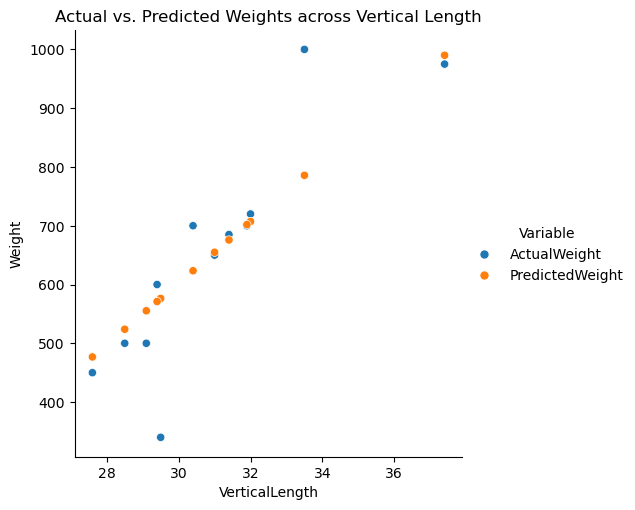

In [101]:
sns.relplot(data=finalMelt, x='VerticalLength', y='Value', hue='Variable', kind='scatter')
plt.title('Actual vs. Predicted Weights across Vertical Length')
plt.ylabel('Weight')
plt.show()

To verify a single feature trajectory across the data, the `lmplot()` function from Seaborn displays a linear fit alongside the filtered Bream subset data points.

**Code Explanation** `sns.relplot()` creates a flexible statistical scatter plot graph. Using `hue='Variable'` splits our data points into distinct categorical colors, mapping our linear `PredictedWeight` points directly against our scattered `ActualWeight` reference points.

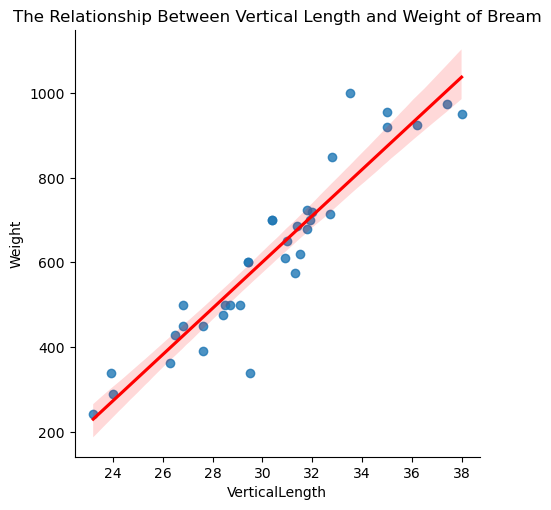

In [75]:
sns.lmplot(data=bream, x='VerticalLength', y='Weight', line_kws={'color':'red'}).set(
    title='The Relationship Between Vertical Length and Weight of Bream'); #plotting a linear regression

**Interpretation of the Linear Regression Lines**

- Both plots show a clear, strong positive linear trajectory between the length of a Bream and its weight

- The data points cluster closely around the liearn trend line across smaller length measurements, though we can see a slight upwards curve starting to form at higher lengths. This suggests that while a linear model is highly effective, the relationship may have a subtle exponential or polynomial characteristic as fish grow larger.

## Plot the Residuals

**Calculate Residual Values**

A residual is the exact difference between the actual observed value and the value predicted by our regression line ($e = y - \hat{y}$). Plotting residuals helps us verify if our model satisfies the linear regression assumption of constant error variance (homoscedasticity).

In [89]:
final['Residual'] = final['ActualWeight'] - final['PredictedWeight']
final.head()

,VerticalLength,ActualWeight,PredictedWeight,Residual
0,32.0,720.0,707.192175,12.807825
1,29.5,340.0,576.265578,-236.265578
2,31.9,700.0,701.955111,-1.955111
3,31.4,685.0,675.769792,9.230208
4,29.4,600.0,571.028514,28.971486


**Generate a Residual Scatter Plot**

Mapping out the calcuated residuals against the independent variable

**Code Explanation**
* `sns.scatterplot()` maps out coordinate points for errors.
* `plt.axhline(y=0, ...)` draws a reference baseline at zero error. Points resting directly on this line represent perfect predictions.
* `s=80` controls individual point marker sizes for readability.

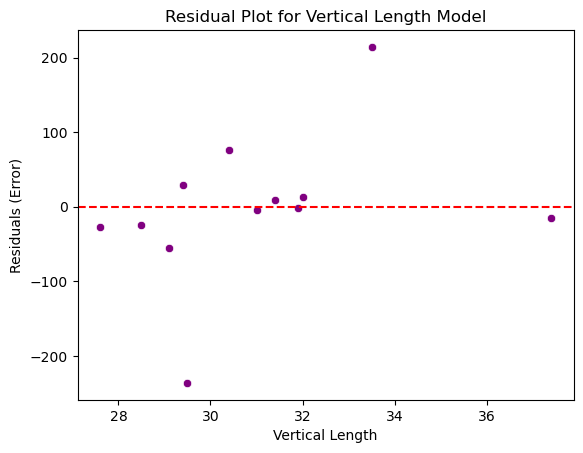

In [90]:
sns.scatterplot(data=final, x='VerticalLength', y='Residual', color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot for Vertical Length Model')
plt.xlabel('Vertical Length')
plt.ylabel('Residuals (Error)')
plt.show()

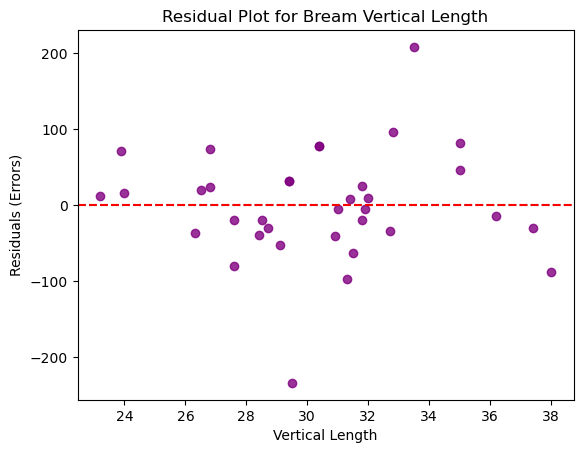

In [127]:
sns.residplot(data=bream, x='VerticalLength', y='Weight', color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot for Bream Vertical Length')
plt.xlabel('Vertical Length')
plt.ylabel('Residuals (Errors)')
plt.show()